In [65]:
base_dir = '/scratch/mjehangir/manuscript_figures/figures'
setwd(base_dir)

In [66]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
#library(ggpubr)
library(tidyverse)
library(readxl)
#library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
#library(GGally)
library(data.table)  # For fread()

In [67]:
final_df = read.csv(file = "final_merged_for_correlation_analysis_v3.tsv", header = TRUE, sep = "\t")

In [68]:
nrow(final_df)

[1] 1155

In [69]:
head(final_df, n=2)

,SampleID,assigned_arm,chr,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm,arm_call,arm_num_seg,arm_cr_wmean,type,total_size,SVs_density
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.2787279,0,0.1978753,2732.75,10,q,0,5,0.9870386,DEL,159358,0.0016933354
2,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.2787279,0,0.1978753,2732.75,10,q,0,5,0.9870386,DUP,23673,0.0002515489


In [70]:
final_df_transformed <- final_df %>%
 filter(!is.na(arm_call)) %>%  # Remove NA values
  mutate(Group = case_when(
    arm_call %in% c(1, -1) ~ "aneuploidy",
    arm_call == 0 ~ "euploidy",
   TRUE ~ NA_character_  # Ensure other values are not included
 )) %>%
  filter(!is.na(Group)) %>%  # Remove rows where Group is NA
 select(Group, SVs_density, type, SampleID, chr, arm, arm_call, arm_cr_wmean, proportion_gain, proportion_loss)


In [71]:
#filter
#final_df_transformed = final_df_transformed %>% filter(SVs_density < 10 & SVs_density > 0) 

In [72]:
head(final_df_transformed, n=20)

,Group,SVs_density,type,SampleID,chr,arm,arm_call,arm_cr_wmean,proportion_gain,proportion_loss
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,euploidy,1.693335e-03,DEL,2436A,chr10,q,0,0.9870386,0.000000000,0.197875307
2,euploidy,2.515489e-04,DUP,2436A,chr10,q,0,0.9870386,0.000000000,0.197875307
3,euploidy,1.977104e-03,DEL,2436A,chr11,p,0,1.0067300,0.000000000,0.000000000
4,euploidy,1.893591e-03,DEL,2436A,chr12,p,0,1.0909572,0.000000000,0.000000000
5,euploidy,2.777319e+00,INV,2436A,chr12,p,0,1.0909572,0.000000000,0.000000000
6,euploidy,1.684900e-03,DEL,2436A,chr12,q,0,1.0029376,0.000000000,0.000000000
7,euploidy,2.194209e-01,INV,2436A,chr12,q,0,1.0029376,0.000000000,0.000000000
8,euploidy,1.365601e-03,DEL,2436A,chr14,q,0,1.0114610,0.000000000,0.000000000
9,euploidy,1.244814e-03,DEL,2436A,chr15,q,0,0.9820486,0.019408147,0.000000000


In [73]:
tail(final_df_transformed, n=20)

,Group,SVs_density,type,SampleID,chr,arm,arm_call,arm_cr_wmean,proportion_gain,proportion_loss
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
843,euploidy,1.848926e-03,DEL,6605D,chr4,q,0,1.0194632,0.000000000,0
844,euploidy,7.095964e-05,DUP,6605D,chr4,q,0,1.0194632,0.000000000,0
845,euploidy,3.162349e-03,DEL,6605D,chr5,p,0,1.0233004,0.000000000,0
846,euploidy,2.365543e-03,DUP,6605D,chr5,p,0,1.0233004,0.000000000,0
847,euploidy,1.911094e-04,INV,6605D,chr5,p,0,1.0233004,0.000000000,0
848,euploidy,1.794133e-03,DEL,6605D,chr5,q,0,1.0200609,0.000000000,0
849,euploidy,4.979527e-05,INV,6605D,chr5,q,0,1.0200609,0.000000000,0
850,euploidy,1.878418e-03,DEL,6605D,chr6,p,0,1.0357201,0.000000000,0
851,euploidy,1.466503e-04,INV,6605D,chr6,p,0,1.0357201,0.000000000,0


In [74]:
nrow(final_df_transformed)

[1] 862

In [75]:
del_data <- final_df_transformed %>% 
  filter(type == "DEL")

ins_data <- final_df_transformed %>% 
  filter(type == "INS")

dup_data <- final_df_transformed %>% 
  filter(type == "DUP")

inv_data <- final_df_transformed %>% 
  filter(type == "INV")

In [76]:
setwd("/home/mjehangir/Glioma_scripts_Feb_2025/plots_for_fig4/")

In [77]:
head(del_data)

,Group,SVs_density,type,SampleID,chr,arm,arm_call,arm_cr_wmean,proportion_gain,proportion_loss
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,euploidy,0.001693335,DEL,2436A,chr10,q,0,0.9870386,0.00000000,0.1978753
2,euploidy,0.001977104,DEL,2436A,chr11,p,0,1.0067300,0.00000000,0.0000000
3,euploidy,0.001893591,DEL,2436A,chr12,p,0,1.0909572,0.00000000,0.0000000
4,euploidy,0.001684900,DEL,2436A,chr12,q,0,1.0029376,0.00000000,0.0000000
5,euploidy,0.001365601,DEL,2436A,chr14,q,0,1.0114610,0.00000000,0.0000000
6,euploidy,0.001244814,DEL,2436A,chr15,q,0,0.9820486,0.01940815,0.0000000


Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 0.01, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 0.008, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 39 rows containing missing values or values outside the scale range
(`geom_violin()`).”


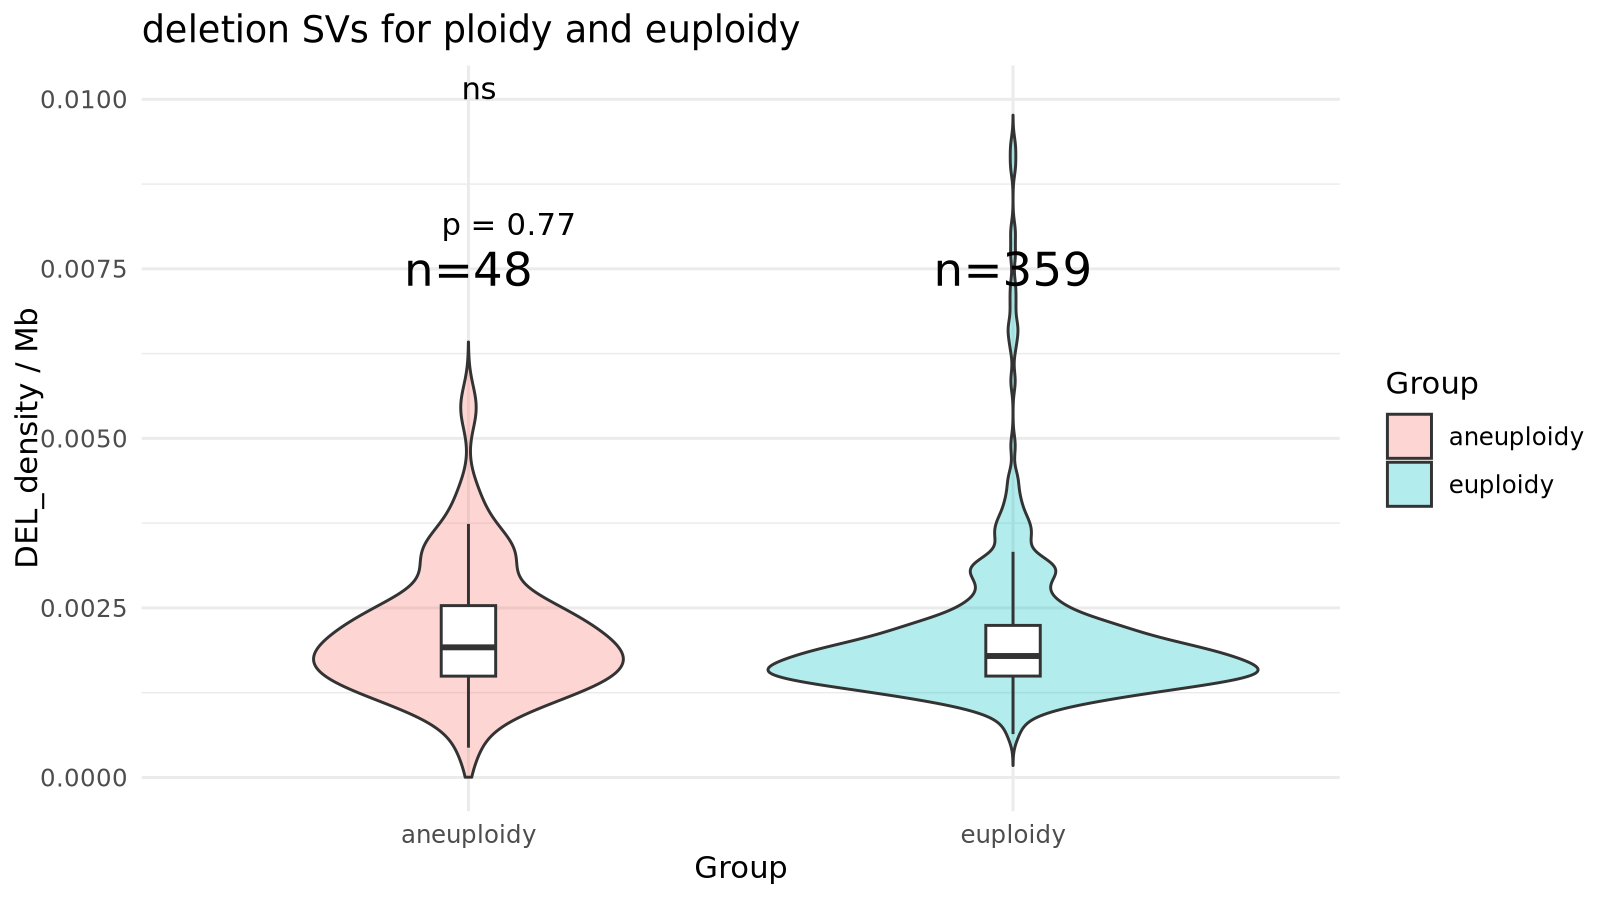

In [80]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 8, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(del_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 2, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test", label = "p.signif", label.y = 0.01, label.size = 5.9) +  
  stat_compare_means(method = "t.test", label = "p.format", label.y = 0.008, label.size = 5.9) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 0.0075, label = paste0("n=", length(x)))), 
               geom = "text", size = 5.9, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DEL_density / Mb", size = 12) +
  ggtitle("deletion SVs for ploidy and euploidy") +  # Axis labels
  theme_minimal() + ylim(0.000001, 0.01)

In [36]:
pdf(file = "deletions_svs_plot01.pdf", width = 8, height = 4.5)
ggplot(del_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 2, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 0.01, label.size = 5.9) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 0.008, label.size = 5.9) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 0.0075, label = paste0("n=", length(x)))), 
               geom = "text", size = 5.9, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DEL_density", size = 12) +
  ggtitle("deletion SVs for ploidy and euploidy") +  # Axis labels
  theme_minimal() + ylim(0.000001, 0.01)
dev.off()

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 0.01, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 0.008, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 19 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 39 rows containing missing values or values outside the scale range
(`geom_violin()`).”


pdf 
  2

In [37]:
head(ins_data)

,Group,SVs_density,type,SampleID,chr,arm,arm_call,arm_cr_wmean,proportion_gain,proportion_loss
,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
1,aneuploidy,0.002162798,INS,3988,chr10,p,1,1.2123989,0.793074455,0.000000000
2,euploidy,0.001868951,INS,3988,chr10,q,0,1.0142161,0.006383081,0.000000000
3,aneuploidy,0.002608084,INS,3988,chr11,p,-1,0.7432257,0.000000000,0.899544934
4,euploidy,0.002072102,INS,3988,chr11,q,0,0.9874770,0.000000000,0.000000000
5,aneuploidy,0.002844173,INS,3988,chr12,p,1,1.4644505,0.930929683,0.000000000
6,euploidy,0.001941714,INS,3988,chr12,q,0,1.0222449,0.000000000,0.004110072


Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 0.0057, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 0.0054, :
“Ignoring unknown parameters: `label.size`”


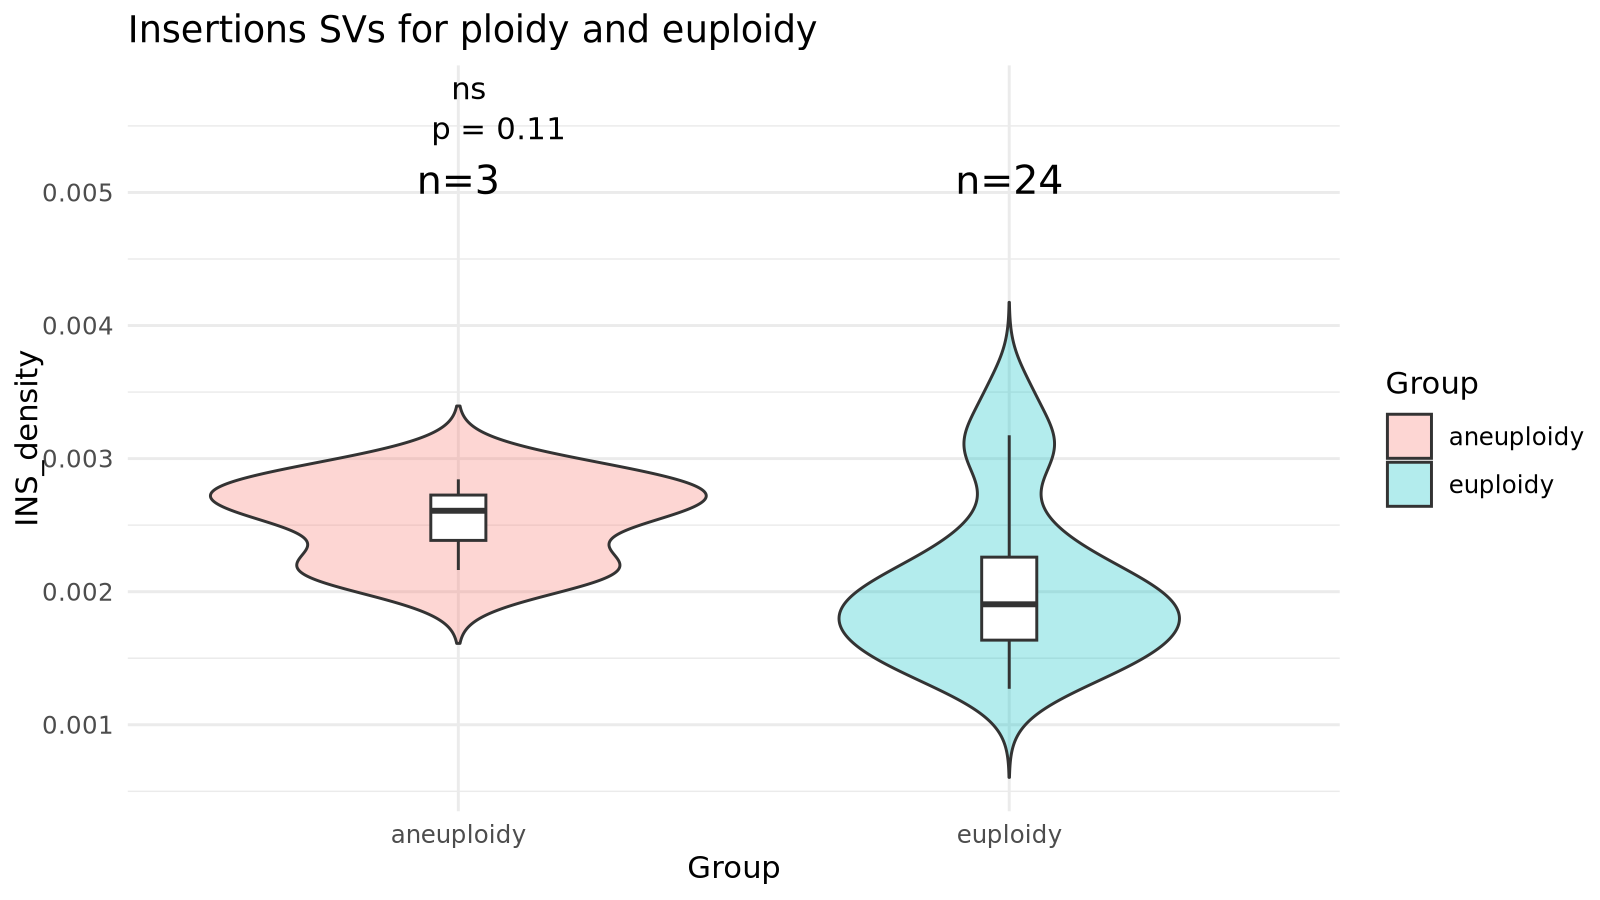

In [38]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 8, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(ins_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 0.0057, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 0.0054, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 0.0051, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INS_density/Mb", size = 12) +
  ggtitle("Insertions SVs for ploidy and euploidy") +  # Axis labels
  theme_minimal()

In [39]:
pdf(file = "insertions_svs_plot01.pdf", width = 8, height = 4.5)
ggplot(ins_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 0.0057, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 0.0054, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 0.0051, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INS_density/Mb", size = 12) +
  ggtitle("Insertions SVs for ploidy and euploidy") +  # Axis labels
  theme_minimal()
dev.off()

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 0.0057, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 0.0054, :
“Ignoring unknown parameters: `label.size`”


pdf 
  2

Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 203 rows containing missing values or values outside the scale range
(`geom_violin()`).”


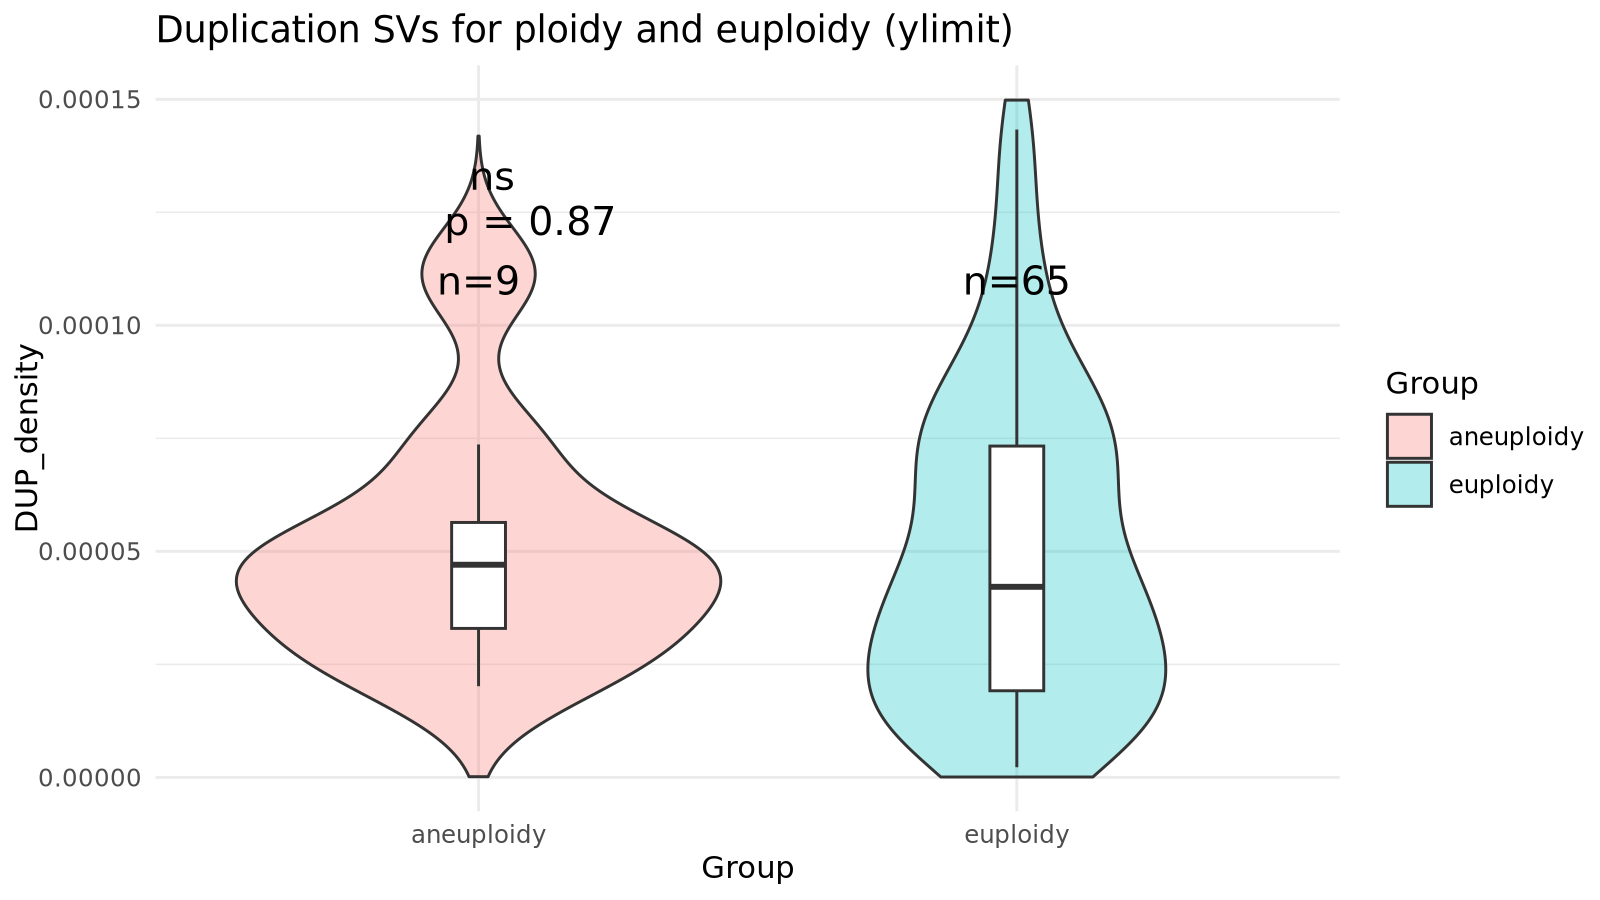

In [40]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 8, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(dup_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  stat_compare_means(method = "t.test",  
                     label = "p.signif", label.y = 0.00013, size = 5) +  # Add significance stars
  stat_compare_means(method = "t.test",  
                     label = "p.format", label.y = 0.00012, size = 5) +  # Add exact p-values
  stat_summary(fun.data = function(x) return(data.frame(y = 0.00011, 
                                                       label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DUP_density/Mb", size = 12) +
  ggtitle("Duplication SVs for ploidy and euploidy (ylimit)") +
  theme_minimal() +
  ylim(0, 0.00015)


In [41]:
pdf(file = "duplications_main_01_svs_plot01.pdf", width = 8, height = 4.5)
ggplot(dup_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 0.00013, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 0.00012, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 0.00011, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DUP_density/Mb", size = 12) +
  ggtitle("Duplication SVs for ploidy and euploidy (ylimit)") +  # Axis labels
  theme_minimal() + ylim(0, 0.00015)
dev.off()

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 0.00013, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 0.00012, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 99 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 203 rows containing missing values or values outside the scale range
(`geom_violin()`).”


pdf 
  2

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 6, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 5, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 157 rows containing missing values or values outside the scale range
(`geom_violin()`).”


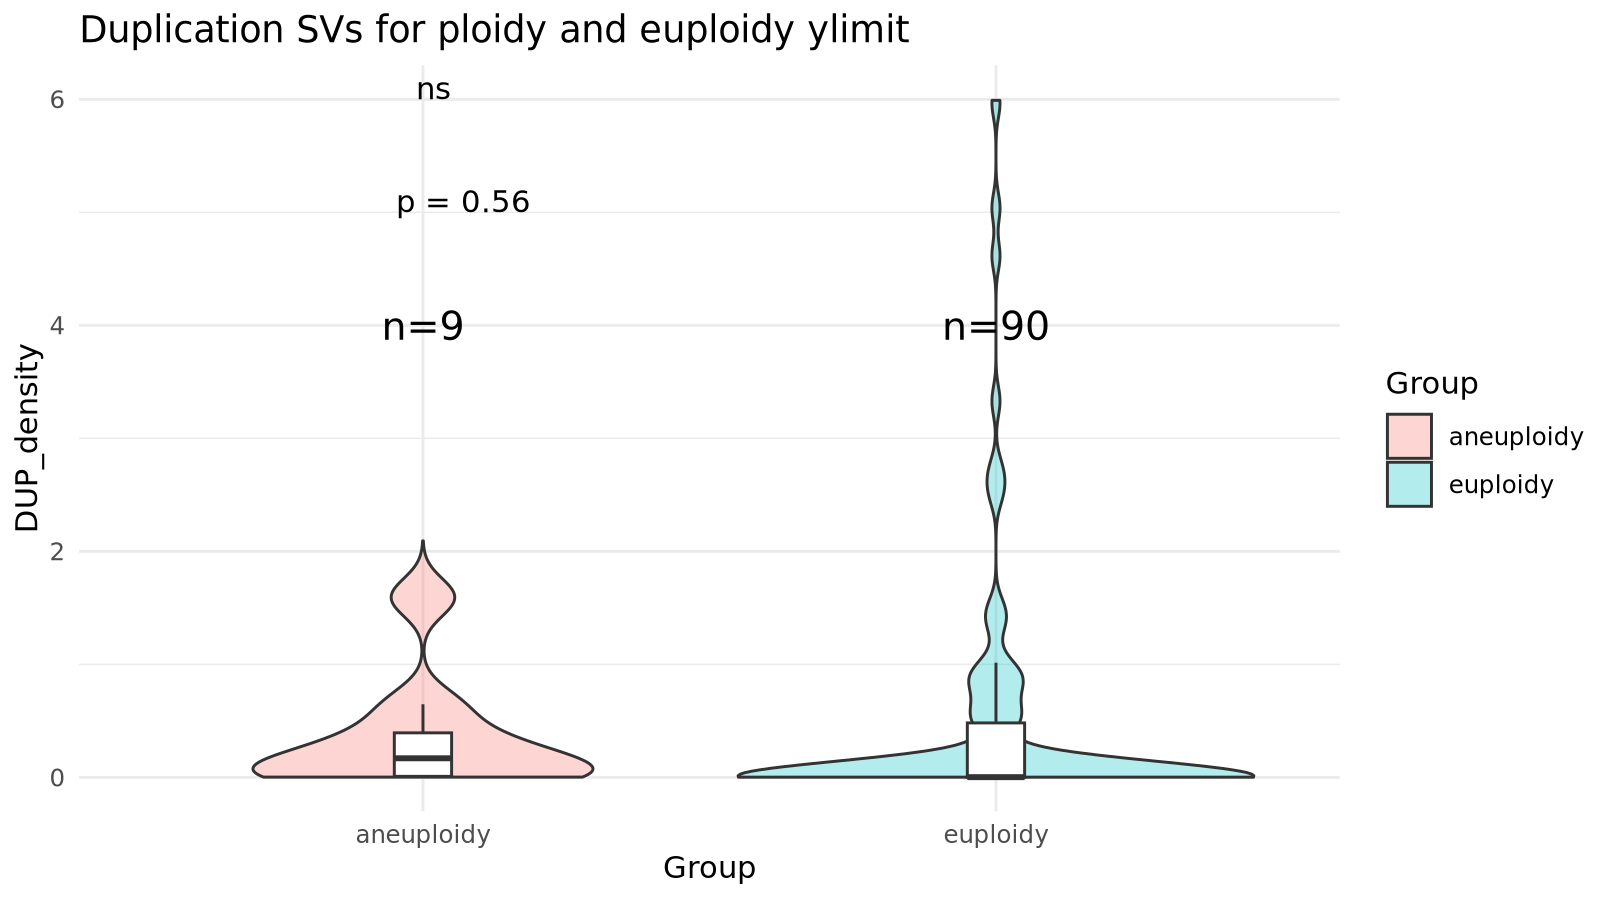

In [42]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 8, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(dup_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 6, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 5, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 4, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DUP_density/Mb", size = 12) +
  ggtitle("Duplication SVs for ploidy and euploidy ylimit") +  # Axis labels
  theme_minimal() + ylim(0.00015, 6)

In [43]:
pdf(file = "duplications_suppl_01_svs_plot01.pdf", width = 8, height = 4.5)
ggplot(dup_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 6, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 5, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 4, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "DUP_density/Mb", size = 12) +
  ggtitle("Duplication SVs for ploidy and euploidy ylimit") +  # Axis labels
  theme_minimal() + ylim(0.00015, 6)
dev.off()

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 6, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 5, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 74 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 157 rows containing missing values or values outside the scale range
(`geom_violin()`).”


pdf 
  2

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 10, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 9, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 184 rows containing missing values or values outside the scale range
(`geom_violin()`).”


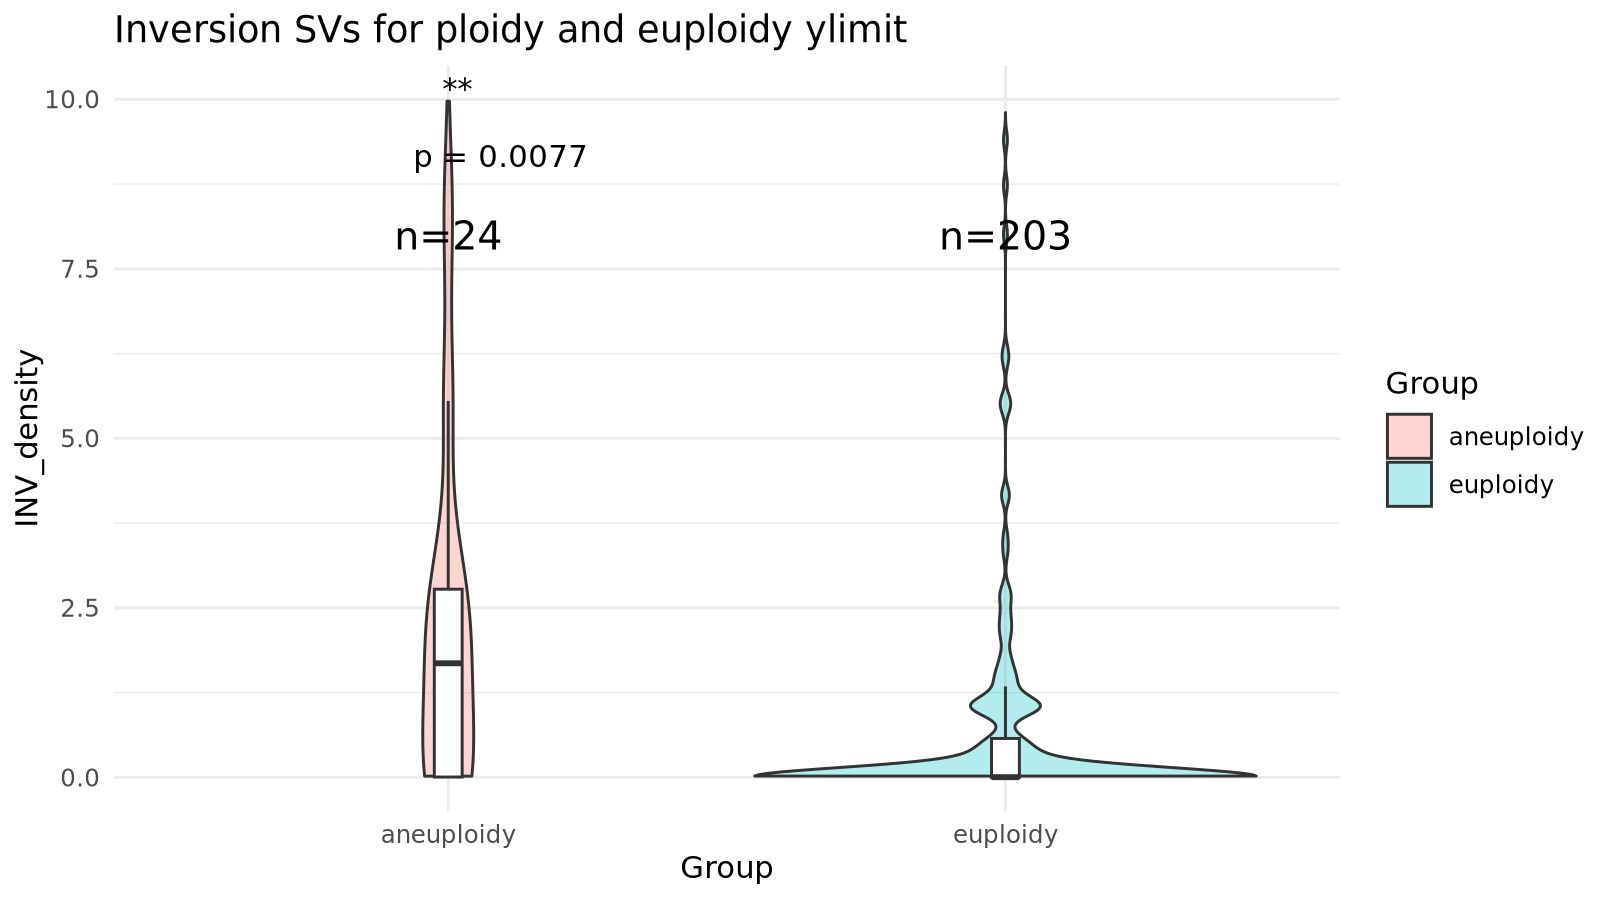

In [44]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 8, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(inv_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.05, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 10, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 9, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 8, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density/Mb", size = 12) +
  ggtitle("Inversion SVs for ploidy and euploidy ylimit") +  # Axis labels
  theme_minimal() + ylim(0, 10)

In [45]:
pdf(file = "inversions_main_01_svs_plot01.pdf", width = 8, height = 4.5)

ggplot(inv_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.05, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 10, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 9, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 8, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density/Mb", size = 12) +
  ggtitle("Inversion SVs for ploidy and euploidy ylimit") +  # Axis labels
  theme_minimal() + ylim(0, 10)
dev.off()

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 10, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 9, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Removed 9 rows containing non-finite outside the scale range
(`stat_summary()`).”
Warning message:
“Removed 184 rows containing missing values or values outside the scale range
(`geom_violin()`).”


pdf 
  2

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 99, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 98, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error in `t.test.default()`:
! not enough 'x' observations”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:

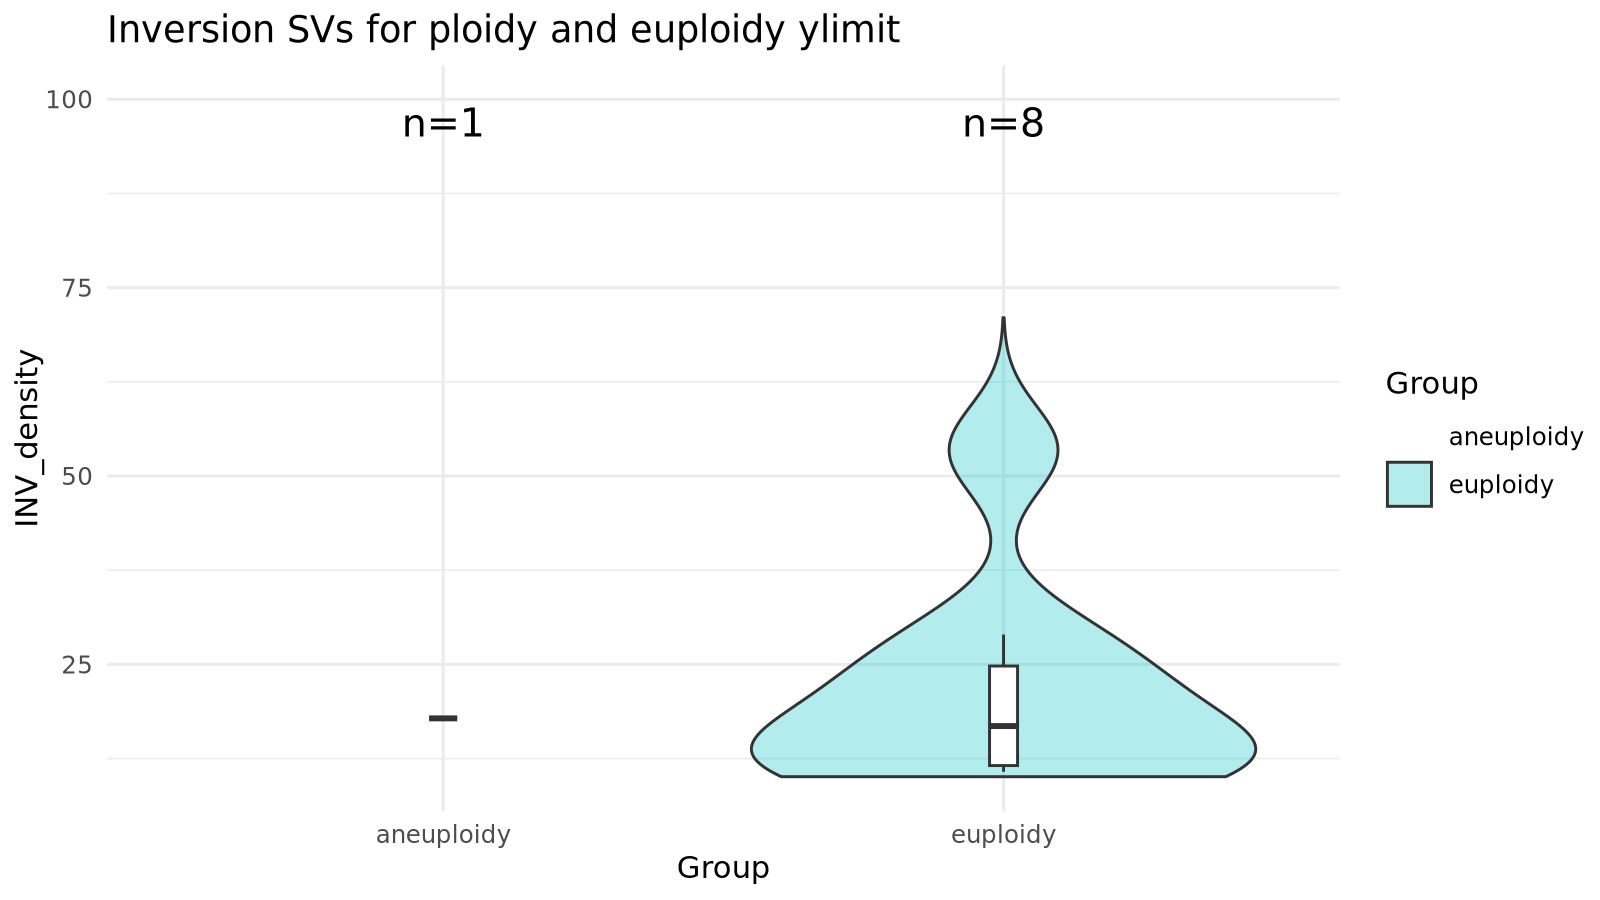

In [49]:
library(ggplot2)
library(ggpubr)

options(repr.plot.width = 8, repr.plot.height = 4.5, repr.plot.res = 200)

ggplot(inv_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.05, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 99, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 98, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 97, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density/Mb", size = 12) +
  ggtitle("Inversion SVs for ploidy and euploidy ylimit") +  # Axis labels
  theme_minimal() + ylim(10, 100)

In [50]:
pdf(file = "inversions_suppl_01_svs_plot01.pdf", width = 8, height = 4.5)
ggplot(inv_data, aes(x = Group, y = SVs_density, fill = Group)) +
  geom_violin(trim = FALSE, alpha = 0.3) +  # Draw the violin plot
  geom_boxplot(width = 0.05, fill = "white", outlier.shape = NA) +  # Add boxplot inside violin
  #geom_point(aes(color = Group), size = 1, alpha = 0.7) +  # Color dots by Group with alpha
  stat_compare_means(method = "t.test",  label = "p.signif", label.y = 99, label.size = 5) +  
  stat_compare_means(method = "t.test",  label = "p.format", label.y = 98, label.size = 5) +  
  stat_summary(fun.data = function(x) return(data.frame(y = 97, label = paste0("n=", length(x)))), 
               geom = "text", size = 5, color = "black") +  # Add sample size above violin plots
  labs(x = "Group", y = "INV_density/Mb", size = 12) +
  ggtitle("Inversion SVs for ploidy and euploidy ylimit") +  # Axis labels
  theme_minimal() + ylim(10, 100)
dev.off()

Warning message in stat_compare_means(method = "t.test", label = "p.signif", label.y = 99, :
“Ignoring unknown parameters: `label.size`”
Warning message in stat_compare_means(method = "t.test", label = "p.format", label.y = 98, :
“Ignoring unknown parameters: `label.size`”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error in `t.test.default()`:
! not enough 'x' observations”
Warning message:
“Removed 227 rows containing non-finite outside the scale range
(`stat_compare_means()`).”
Warning message:

pdf 
  2

In [56]:
final_df_transformed <- final_df_transformed[!is.na(final_df_transformed$proportion_loss), ]

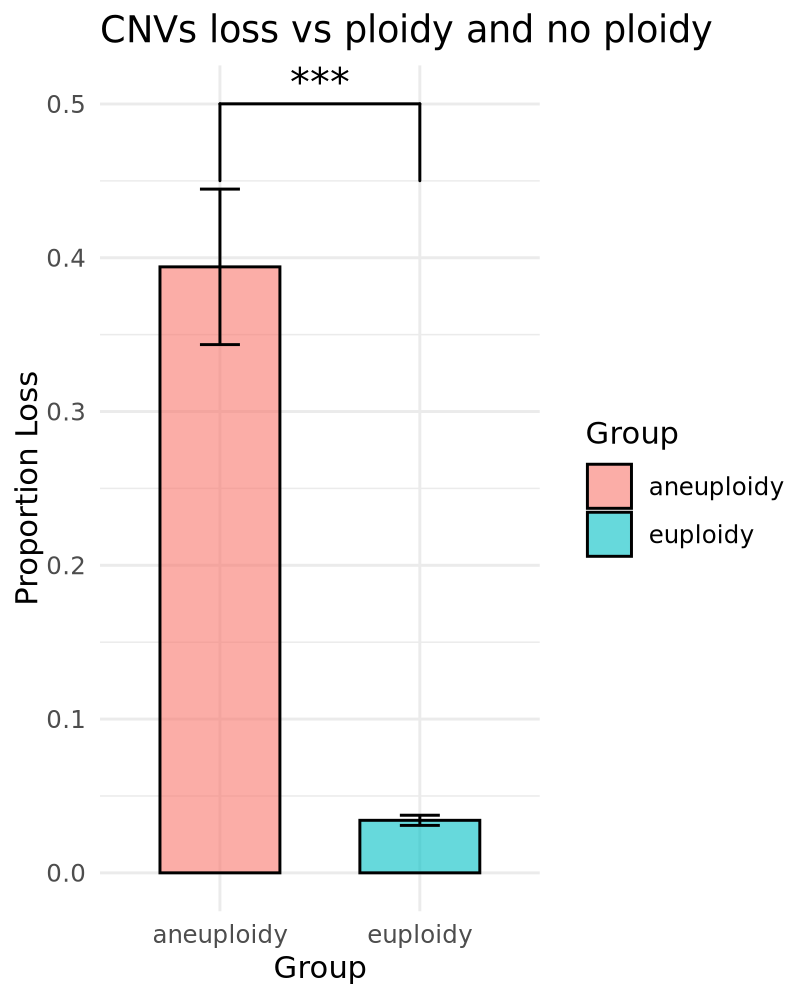

In [62]:
library(ggplot2)
library(ggsignif)

# Define comparisons
comparisons <- list(c("euploidy", "aneuploidy"))

options(repr.plot.width = 4, repr.plot.height = 5, repr.plot.res = 200)

# Create the plot
ggplot(final_df_transformed, aes(x = Group, y = proportion_loss, fill = Group)) +
  stat_summary(fun = mean, geom = "bar", alpha = 0.6, width = 0.6, color = "black") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) +
  geom_signif(comparisons = comparisons,
              map_signif_level = TRUE,
              textsize = 5,
              y_position = max(final_df_transformed$proportion_loss, na.rm = TRUE) * 0.25) +
  labs(x = "Group", y = "Proportion Loss") +
  ggtitle("CNVs loss vs ploidy and no ploidy") +
  theme_minimal()

In [63]:
pdf(file = "CNVs_loss_suppl_01_svs_plot01.pdf", width = 8, height = 4.5)

# Create the plot
ggplot(final_df_transformed, aes(x = Group, y = proportion_loss, fill = Group)) +
#geom_jitter(size = 2) +
  stat_summary(fun = mean, geom = "bar", alpha = 0.6, width = 0.6, color = "black") + # Bar plot of mean values
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) + # Error bars for standard error
  geom_signif(comparisons = comparisons,
              map_signif_level = TRUE,
              textsize = 5,
              y_position = max(final_df_transformed$proportion_loss, na.rm = TRUE) * 0.25) + # Significance bars
  labs(x = "Group", y = "Proportion Loss") +
  ggtitle("CNVs loss vs ploidy and no ploidy") +
  theme_minimal()

dev.off()

pdf 
  2

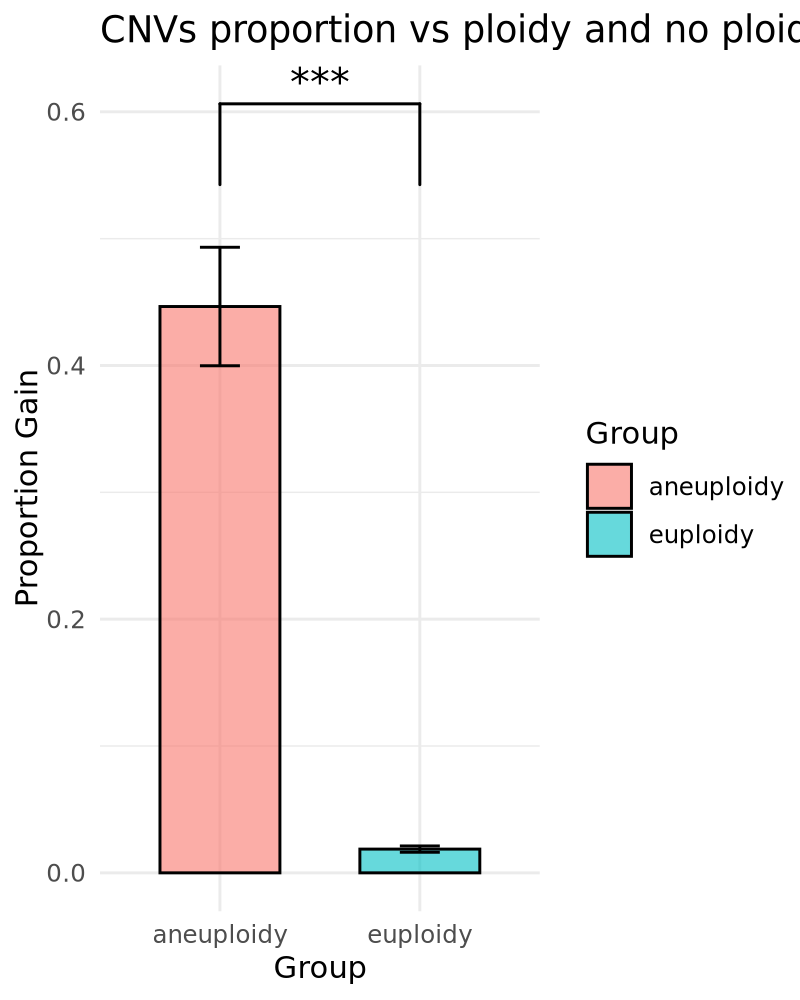

In [64]:
library(ggplot2)
library(ggsignif)

# Define comparisons
comparisons <- list(c("euploidy", "aneuploidy"))

# Create the plot
ggplot(final_df_transformed, aes(x = Group, y = proportion_gain, fill = Group)) +
  stat_summary(fun = mean, geom = "bar", alpha = 0.6, width = 0.6, color = "black") + # Bar plot of mean values
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) + # Error bars for standard error
  geom_signif(comparisons = comparisons, test = "t.test",
              map_signif_level = TRUE,
              textsize = 5,
              y_position = max(final_df_transformed$proportion_loss, na.rm = TRUE) * 0.3) + # Significance bars
  labs(x = "Group", y = "Proportion Gain") +
  ggtitle("CNVs proportion vs ploidy and no ploidy") +
  theme_minimal()


In [61]:
unique(final_df_transformed$Group)

[1] "euploidy"   "aneuploidy"

In [411]:
pdf(file = "CNVs_gain_suppl_01_svs_plot01.pdf", width = 8, height = 4.5)

ggplot(final_df_transformed, aes(x = Group, y = proportion_gain, fill = Group)) +
  stat_summary(fun = mean, geom = "bar", alpha = 0.6, width = 0.6, color = "black") + # Bar plot of mean values
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) + # Error bars for standard error
  geom_signif(comparisons = comparisons, test = "t.test",
              map_signif_level = TRUE,
              textsize = 5,
              y_position = max(final_df_transformed$proportion_loss, na.rm = TRUE) * 0.3) + # Significance bars
  labs(x = "Group", y = "Proportion Gain") +
  ggtitle("CNVs gain vs ploidy and no ploidy") +
  theme_minimal()

dev.off()

Warning message:
“Computation failed in `stat_signif()`.
Caused by error in `if (scales$x$map(comp[1]) == data$group[1] | manual) ...`:
! missing value where TRUE/FALSE needed”


pdf 
  2